# HR Analytics Job Change EDA

## Objective
Analyze the factors influencing candidate job-switching behavior through exploratory data analysis.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
# Importing Important Libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import Dataset
df = pd.read_csv('/content/data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'training_hours', 'target'],
      dtype='object')

# Questions


1.  How many candidates are present in the dataset?
2.   What are the data types of each feature?
3.   Are there any missing values?
4.   Are there any duplicate records?
5.   What is the distribution of numerical features?














In [5]:
df.shape

(19158, 13)

In [6]:
df.describe()

,enrollee_id,city_development_index,experience,training_hours,target
count,19158.000000,18679.000000,19093.000000,18392.000000,19158.000000
mean,16875.358179,0.828951,9.928036,65.185787,0.249348
std,9616.292592,0.123334,6.505268,59.885626,0.432647
min,1.000000,0.448000,0.000000,1.000000,0.000000
25%,8554.250000,0.740000,4.000000,23.000000,0.000000
50%,16982.500000,0.903000,9.000000,47.000000,0.000000
75%,25169.750000,0.920000,16.000000,88.000000,0.000000
max,33380.000000,0.949000,20.000000,336.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [8]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,479
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [9]:
# Handling Missing Values using Pandas

def impute_missing_values(df):
    df = df.copy()
    summary = {}

    for col in df.columns:
        missing_count = df[col].isnull().sum()

        if missing_count == 0:
            continue

        if col == 'experience':
            numeric_exp = df[col].replace({'<1': '0', '>20': '21'}).astype(float)
            median_val = numeric_exp.median()
            df[col] = df[col].fillna(str(int(median_val)))
            summary[col] = {'strategy': 'median (numeric conversion)', 'fill_value': int(median_val), 'filled_count': missing_count}

        elif df[col].dtype in ['int64', 'float64']:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            summary[col] = {'strategy': 'median', 'fill_value': round(median_val, 4), 'filled_count': missing_count}

        else:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            summary[col] = {'strategy': 'mode', 'fill_value': mode_val, 'filled_count': missing_count}

    print(f"  Remaining missing values: {df.isnull().sum().sum()}")


    return df, summary


df_clean, report = impute_missing_values(df)

  Remaining missing values: 0


In [45]:
# Handling Outlier Using IQR Method

def handling_Outliers_values(df):
    df = df.copy()
    summary = {}

    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

            if outliers_count > 0:
                df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
                df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
                summary[col] = {'strategy': 'IQR', 'lower_bound': lower_bound,
                                'upper_bound': upper_bound, 'outliers_count': outliers_count}

    return df, summary

df_clean, report = handling_Outliers_values(df)

In [11]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
19153,False
19154,False
19155,False
19156,False


In [12]:
df.describe()

,enrollee_id,city_development_index,experience,training_hours,target
count,19158.000000,18679.000000,19093.000000,18392.000000,19158.000000
mean,16875.358179,0.828951,9.928036,65.185787,0.249348
std,9616.292592,0.123334,6.505268,59.885626,0.432647
min,1.000000,0.448000,0.000000,1.000000,0.000000
25%,8554.250000,0.740000,4.000000,23.000000,0.000000
50%,16982.500000,0.903000,9.000000,47.000000,0.000000
75%,25169.750000,0.920000,16.000000,88.000000,0.000000
max,33380.000000,0.949000,20.000000,336.000000,1.000000


# Univariate Analysis

### Demographics

6.  What is the gender distribution of candidates?
7.   What is the distribution of education levels?
8.   Which major disciplines are most common?
9.   How many candidates are currently enrolled in a university?







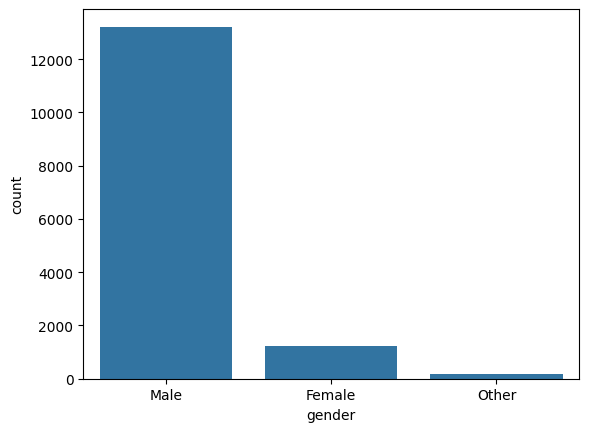


 Insights:
Male has highest number of the candidates campare to other gender type.


In [13]:
# 6
sns.countplot(x='gender', data=df)
plt.show()

print('\n Insights:')
print('Male has highest number of the candidates campare to other gender type.')

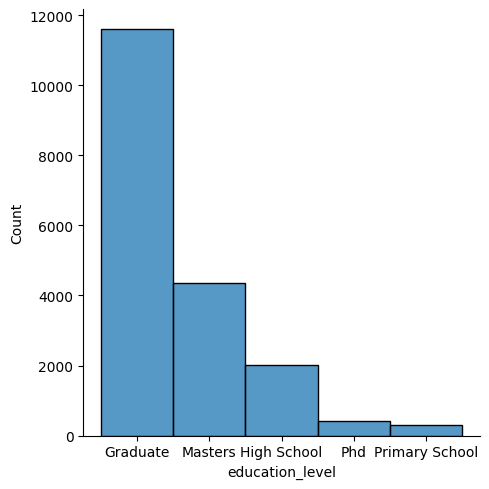



Insights :



In [14]:
#7
sns.displot(x='education_level',data = df)
plt.show()

print('\n')
print('Insights :')
print('')

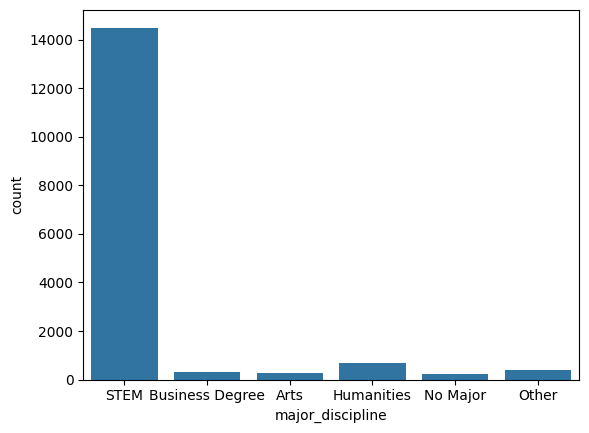



Insights :



In [15]:
# 8
sns.countplot(x='major_discipline', data=df)
plt.show()

print('\n')
print('Insights :')
print('')

<Axes: xlabel='enrolled_university', ylabel='count'>

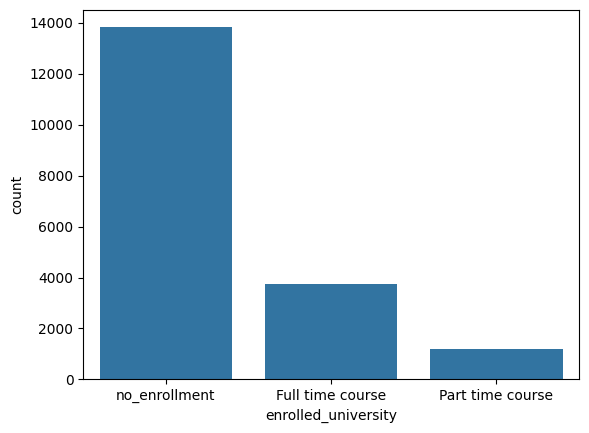

In [16]:
# 9
sns.countplot(x='enrolled_university', data=df)

## Experience


10.   What is the distribution of candidate experience?
11.   How are training hours distributed?
12.   Which company sizes are most common?
13.   Which company types employ the most candidates?







<Axes: xlabel='experience', ylabel='Count'>

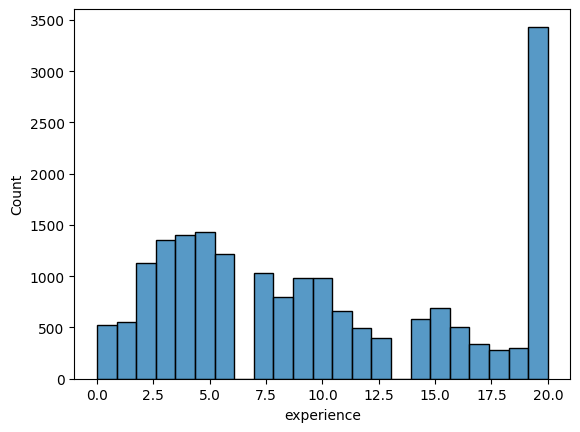

In [17]:
# 10
sns.histplot(x='experience',data=df)

<Axes: xlabel='training_hours', ylabel='Count'>

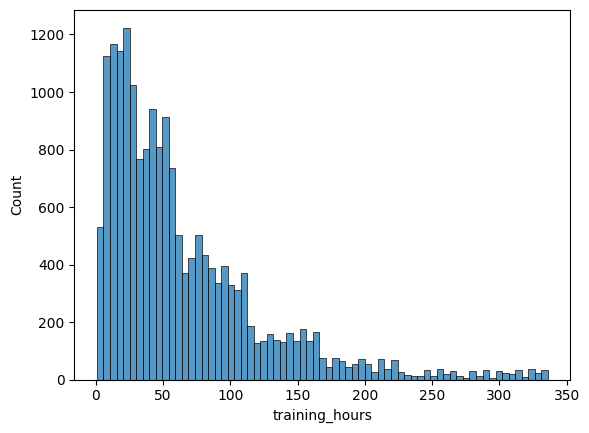

In [18]:
# 11
sns.histplot(x='training_hours',data = df)

<Axes: xlabel='company_size', ylabel='count'>

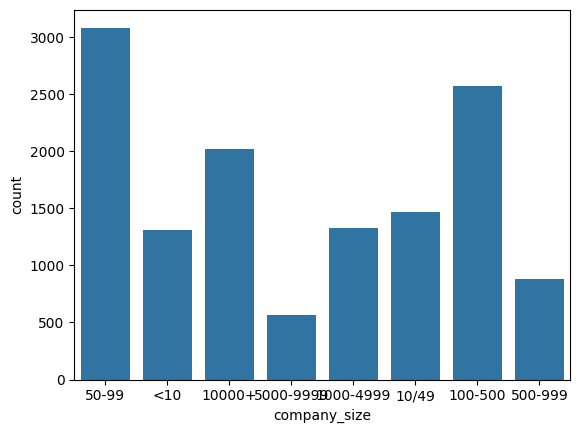

In [19]:
# 12
sns.countplot(x='company_size',data = df)

<Axes: xlabel='company_type', ylabel='count'>

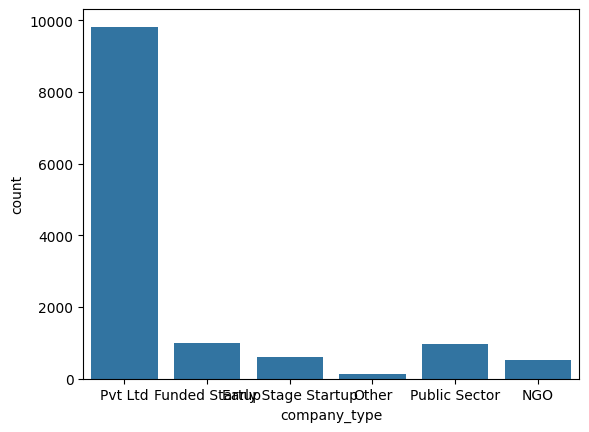

In [20]:
# 13
sns.countplot(x='company_type',data = df)

## Target Variable Analysis

14.   What percentage of candidates are looking for a job change?
15.   Is the dataset balanced or imbalanced?





In [21]:
#14
# Count target values
target_counts = df['target'].value_counts()

# Percentage distribution
target_percentage = df['target'].value_counts(normalize=True) * 100

print(target_percentage)

target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


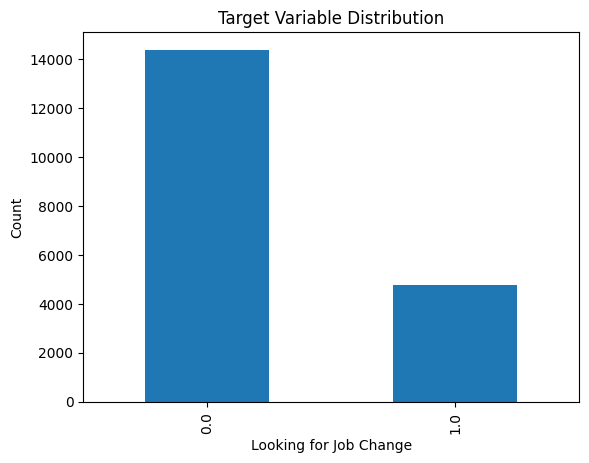

In [22]:
# 15
target_counts.plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xlabel('Looking for Job Change')
plt.ylabel('Count')
plt.show()

# Bivariate Analysis
* Experience vs Job Change

16.   Does work experience influence job-switching behavior?
17.   Are freshers more likely to change jobs ?


experience
0.0     45.402299
1.0     42.440801
2.0     33.185448
3.0     35.302806
4.0     32.573058
5.0     28.811189
6.0     28.207237
7.0     29.474708
8.0     24.314214
9.0     21.734694
10.0    21.015228
11.0    22.740964
12.0    18.623482
13.0    19.298246
14.0    18.259386
15.0    16.618076
16.0    14.173228
17.0    16.666667
18.0    15.357143
19.0    17.434211
20.0    15.608620
Name: target, dtype: float64


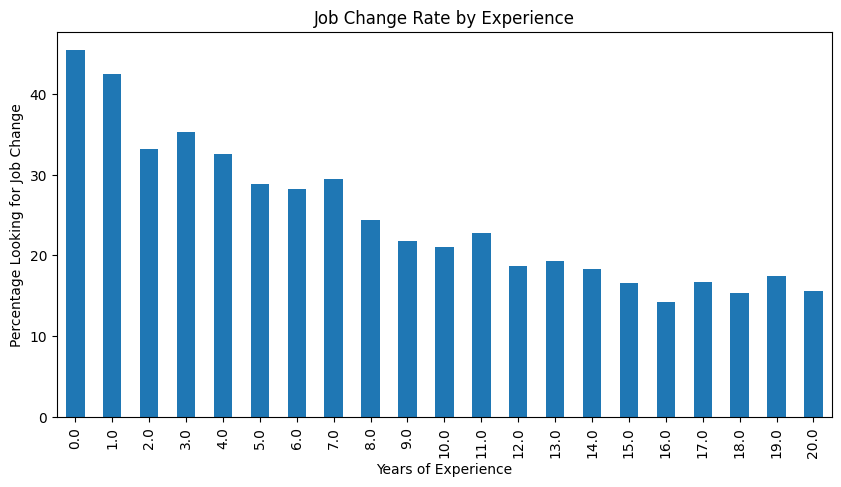

In [23]:
# 16
exp_analysis = df.groupby('experience')['target'].mean() * 100

print(exp_analysis.sort_index())

exp_analysis.sort_index().plot(kind='bar', figsize=(10,5))
plt.title('Job Change Rate by Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Percentage Looking for Job Change')
plt.show()

In [24]:
# 17
fresher_rate = df[df['experience'] >= 1]['target'].mean() * 100
overall_rate = df['target'].mean() * 100

print('Fresher Job change Rate :',fresher_rate)
print('Overall Job change Rate :',overall_rate)

Fresher Job change Rate : 24.32286898928437
Overall Job change Rate : 24.934753105752165


## Education vs Job Change


18.   Which education level has the highest job-switching rate?
19.   Does major discipline affect job-switching decisions?





In [25]:
# 18
education_with_job_change = df.groupby('education_level')['target'].mean() * 100
print(education_with_job_change.sort_values(ascending=False))

education_level
Graduate          27.978962
Masters           21.440037
High School       19.533961
Phd               14.009662
Primary School    13.311688
Name: target, dtype: float64


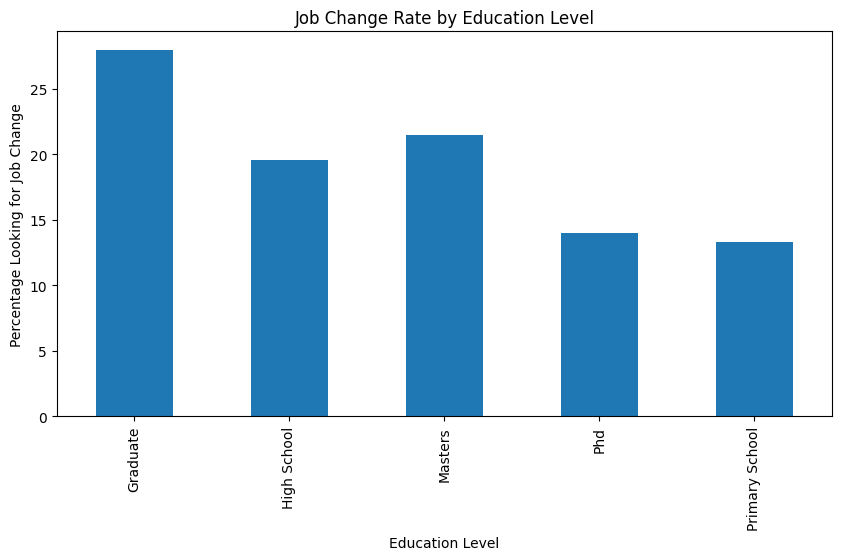

In [26]:
# 19
education_with_job_change.plot(kind='bar', figsize=(10,5))
plt.title('Job Change Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Percentage Looking for Job Change')
plt.show()

## Gender vs Job Change
20. Does job-switching behavior differ by gender?

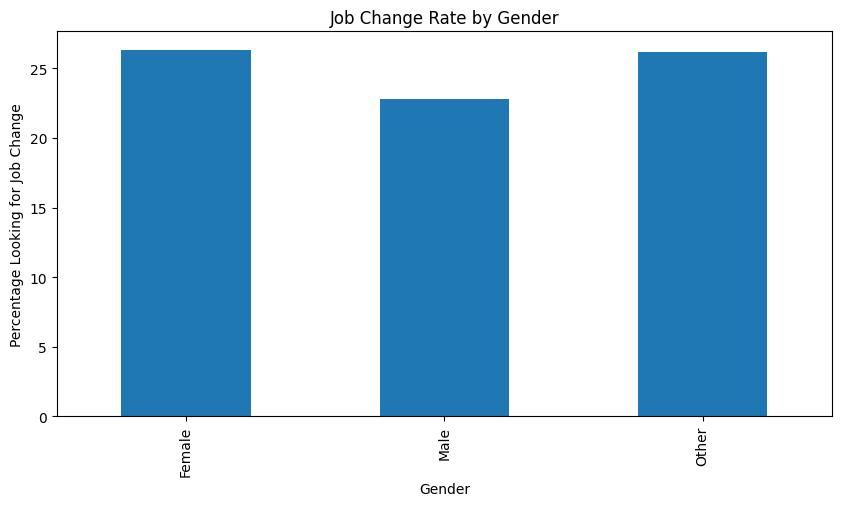

In [27]:
gender_job_switch = df.groupby('gender')['target'].mean() * 100

gender_job_switch.plot(kind='bar', figsize=(10,5))
plt.title('Job Change Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage Looking for Job Change')
plt.show()

## University Enrollment vs Job Change
21. Are candidates currently enrolled in courses more likely to switch jobs?

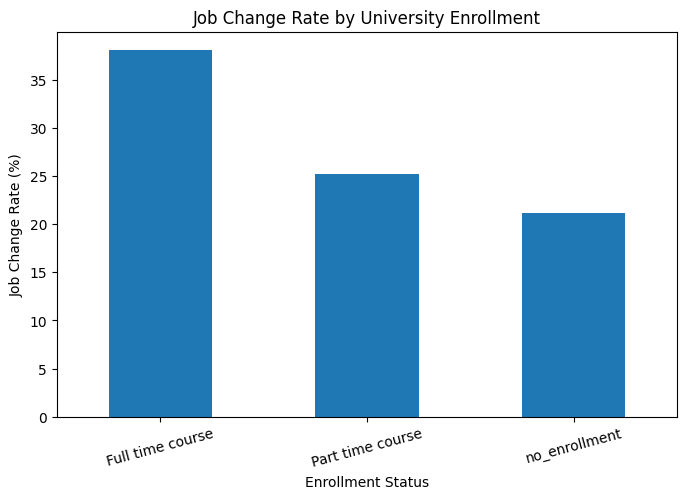


Insights:
enrolled_university
Full time course    38.088901
Part time course    25.208681
no_enrollment       21.140624
Name: target, dtype: float64


In [46]:

uni_job_change = df.groupby('enrolled_university')['target'].mean() * 100

uni_job_change.plot(kind='bar', figsize=(8, 5))
plt.title('Job Change Rate by University Enrollment')
plt.xlabel('Enrollment Status')
plt.ylabel('Job Change Rate (%)')
plt.xticks(rotation=15)
plt.show()

print("\nInsights:")
print(uni_job_change.sort_values(ascending=False))

## Training vs Job Change

22.Do candidates with more training hours tend to switch jobs more frequently?



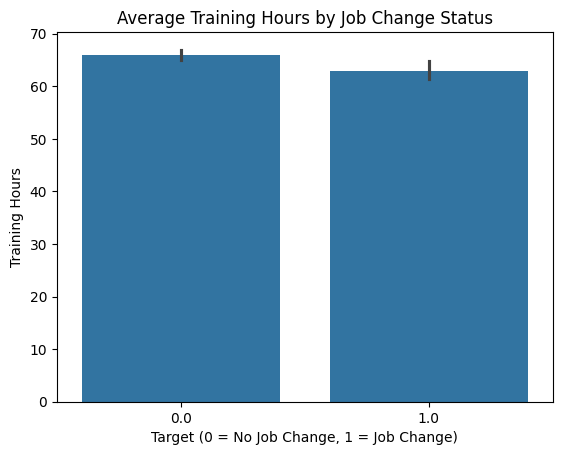



There Equal that chance to change job in any time of training Hours


In [29]:
avg_training = df.groupby('training_hours')['target'].mean() * 100
sns.barplot(x='target',y = 'training_hours',data=df)
plt.title('Average Training Hours by Job Change Status')
plt.xlabel('Target (0 = No Job Change, 1 = Job Change)')
plt.ylabel('Training Hours')
plt.show()

print('\n')
print('There Equal that chance to change job in any time of training Hours')

### Company Factors
23. Does company size influence job-switching behavior?
24. Which company type experiences the highest employee turnover?

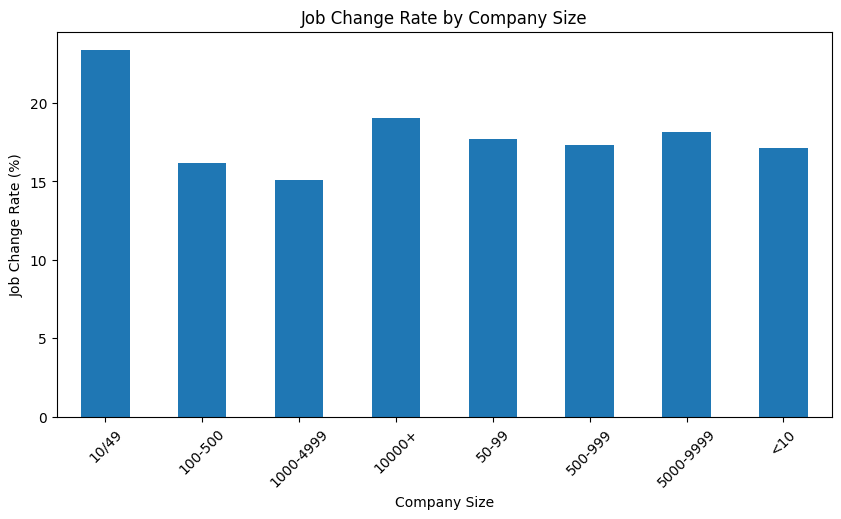

In [30]:
# 23
avg_company_size = df.groupby('company_size')['target'].mean() * 100
avg_company_size

plt.figure(figsize=(10,5))
avg_company_size.plot(kind='bar')
plt.title('Job Change Rate by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Job Change Rate (%)')
plt.xticks(rotation=45)
plt.show()


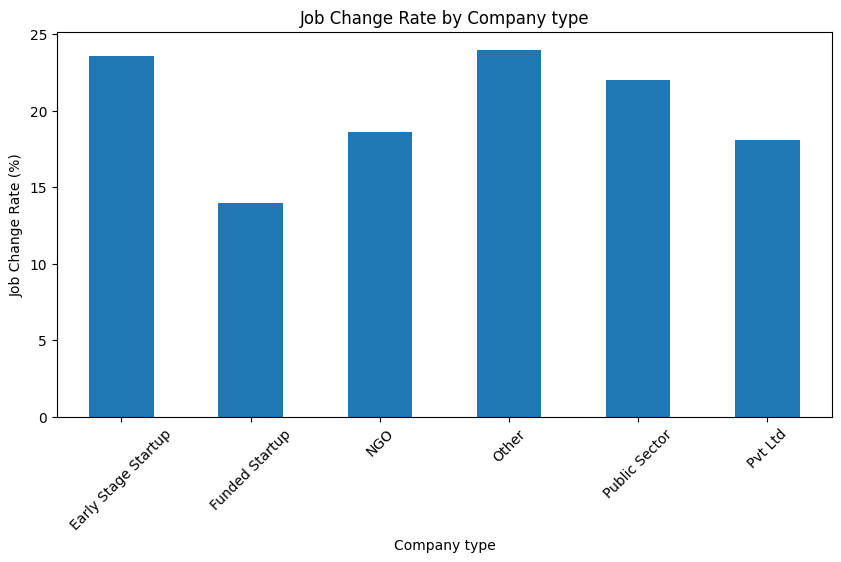


- Company Type X has the highest job change rate.
- Employees working in Company Type X are more likely to seek new opportunities.
- Company type appears to influence employee turnover behavior.



In [31]:
# 24

highest_turnover = df.groupby('company_type')['target'].mean() * 100
highest_turnover

plt.figure(figsize=(10,5))
highest_turnover.plot(kind='bar')
plt.title('Job Change Rate by Company type')
plt.xlabel('Company type')
plt.ylabel('Job Change Rate (%)')
plt.xticks(rotation=45)
plt.show()

print('''
- Company Type X has the highest job change rate.
- Employees working in Company Type X are more likely to seek new opportunities.
- Company type appears to influence employee turnover behavior.
''')

### City Factors
25. Does city development index affect job-switching rates?
26. Are candidates from highly developed cities more likely to seek new opportunities?

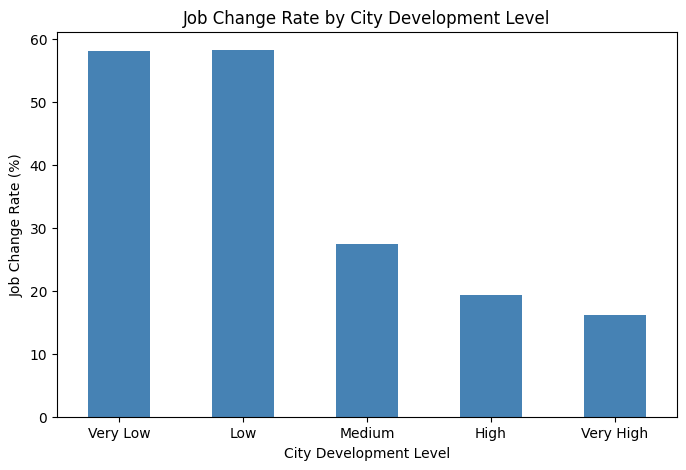


Insights:
Highest switching city level: Low (58.2%)
Lowest switching city level: Very High (16.1%)


In [47]:
# Q25 & Q26 combined ✅
df['city_dev_category'] = pd.cut(
    df['city_development_index'], bins=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

city_job_change = df.groupby('city_dev_category')['target'].mean() * 100

plt.figure(figsize=(8, 5))
city_job_change.plot(kind='bar', color='steelblue')
plt.title('Job Change Rate by City Development Level')
plt.xlabel('City Development Level')
plt.ylabel('Job Change Rate (%)')
plt.xticks(rotation=0)
plt.show()

print("\nInsights:")
print("Highest switching city level:", city_job_change.idxmax(),
      f"({city_job_change.max():.1f}%)")
print("Lowest switching city level:", city_job_change.idxmin(),
      f"({city_job_change.min():.1f}%)")

##📈 Multivariate Analysis
27. How does experience vary across education levels?
28. How does training_hours differ across company sizes?
29. What combination of education and experience leads to the highest
30. job-switching rate?
31. Which candidate profile is most likely to switch jobs?

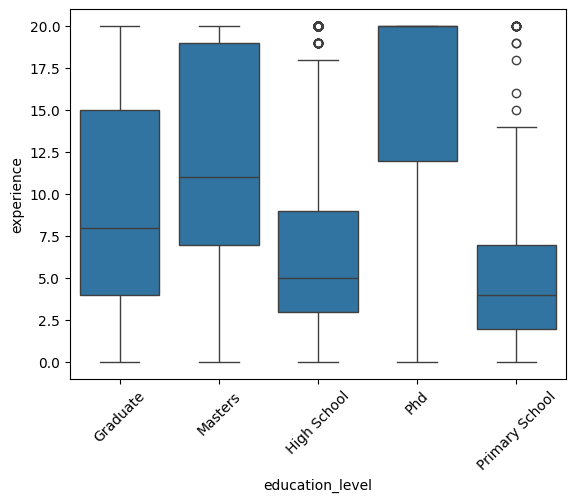


Insgihts :-
    1.Highest experience according the education level is PhD
    2.lowest experience according the education level is Primary School



In [39]:
#27
sns.boxplot(x='education_level', y='experience', data=df)
plt.xticks(rotation=45)
plt.show()

print('''
Insgihts :-
    1.Highest experience according the education level is PhD
    2.lowest experience according the education level is Primary School
''')

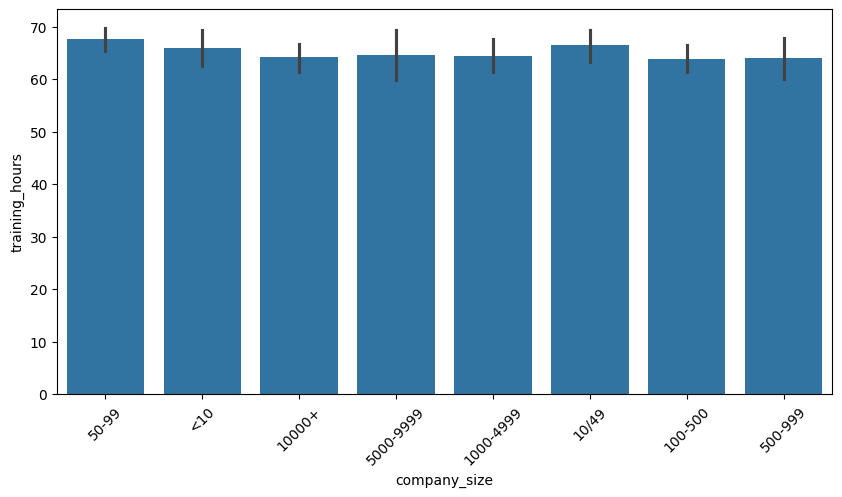


Insgihts :-
    1.Highest training hours in low size company
    2.All comapnay has almost same level of training hours



In [41]:
#28
plt.figure(figsize=(10,5))
sns.barplot(x='company_size', y='training_hours', data=df)
plt.xticks(rotation=45)
plt.show()
print('''
Insgihts :-
    1.Highest training hours in low size company
    2.All comapnay has almost same level of training hours
''')

In [48]:
# 29
# Q29 ✅ — Which education+experience combo has the highest job-switching rate?
pivot = pd.pivot_table(
    df, values='target',
    index='education_level',
    columns='experience',
    aggfunc='mean'
) * 100

# Find the top combo
top_combo = pivot.stack().idxmax()
print(f"Highest switching combo — Education: {top_combo[0]}, Experience: {top_combo[1]}")
print(f"Job switch rate: {pivot.stack().max():.1f}%")

print('''
Insgihts :-
   Insights:
      1. Candidates with PhD and Master's degrees generally have higher work experience compared to other education levels.
      2. Primary School and High School candidates tend to have lower experience levels.
      3. The experience distribution varies significantly across education levels.
      4. Higher educational qualifications are generally associated with greater work experience.
''')

Highest switching combo — Education: Phd, Experience: 0.0
Job switch rate: 66.7%

Insgihts :-
   Insights:
      1. Candidates with PhD and Master's degrees generally have higher work experience compared to other education levels.
      2. Primary School and High School candidates tend to have lower experience levels.
      3. The experience distribution varies significantly across education levels.
      4. Higher educational qualifications are generally associated with greater work experience.



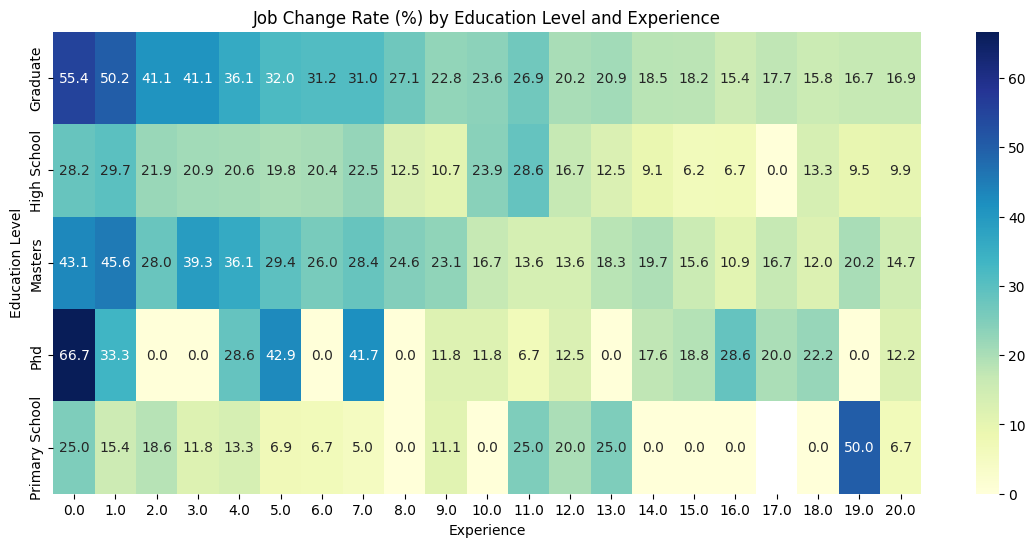


Insights :-
    1. Job-switching rates vary significantly across different combinations of education level and experience.
    2. Candidates with lower experience levels generally show higher job-switching tendencies.
    3. Certain education groups exhibit a higher willingness to switch jobs early in their careers.
    4. As experience increases, the job-switching rate tends to decrease for most education levels.
    5. The combination with the highest percentage represents the candidate group most likely to seek new opportunities.



In [37]:
# 30
pivot_table = pd.pivot_table(
    df,
    values='target',
    index='education_level',
    columns='experience',
    aggfunc='mean'
) * 100

plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlGnBu')

plt.title('Job Change Rate (%) by Education Level and Experience')
plt.xlabel('Experience')
plt.ylabel('Education Level')
plt.show()
print('''
Insights :-
    1. Job-switching rates vary significantly across different combinations of education level and experience.
    2. Candidates with lower experience levels generally show higher job-switching tendencies.
    3. Certain education groups exhibit a higher willingness to switch jobs early in their careers.
    4. As experience increases, the job-switching rate tends to decrease for most education levels.
    5. The combination with the highest percentage represents the candidate group most likely to seek new opportunities.
''')

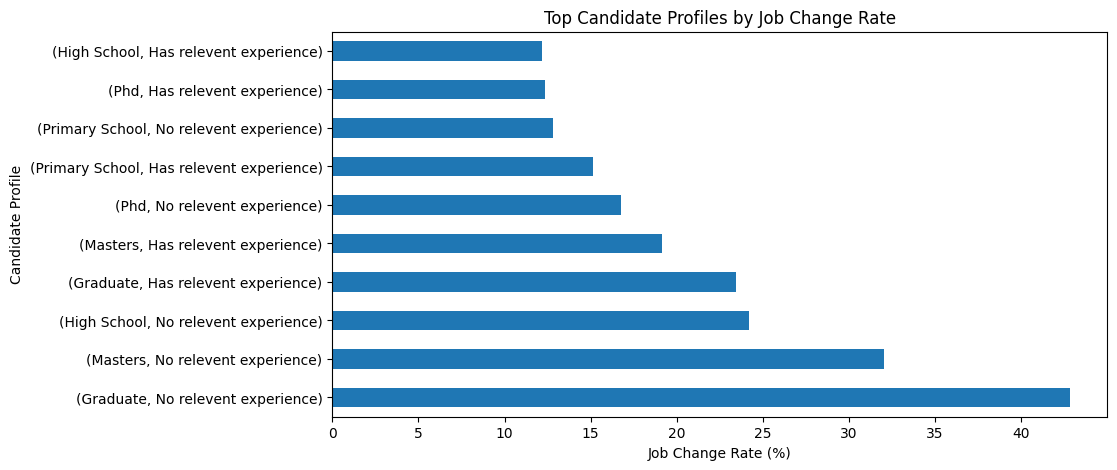



Insights :-
    1. Job-switching rates vary significantly across different combinations of education level and experience.
    2. Candidates with lower experience levels generally show higher job-switching tendencies.
    3. Certain education groups exhibit a higher willingness to switch jobs early in their careers.
    4. As experience increases, the job-switching rate tends to decrease for most education levels.
    5. The combination with the highest percentage represents the candidate group most likely to seek new opportunities.



In [38]:
# 31
profile = (
    df.groupby([
        'education_level',
        'relevent_experience'
    ])['target']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
profile.plot(kind='barh')

plt.title('Top Candidate Profiles by Job Change Rate')
plt.xlabel('Job Change Rate (%)')
plt.ylabel('Candidate Profile')
plt.show()
print('''

Insights :-
    1. Job-switching rates vary significantly across different combinations of education level and experience.
    2. Candidates with lower experience levels generally show higher job-switching tendencies.
    3. Certain education groups exhibit a higher willingness to switch jobs early in their careers.
    4. As experience increases, the job-switching rate tends to decrease for most education levels.
    5. The combination with the highest percentage represents the candidate group most likely to seek new opportunities.
''')

In [44]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'city_103'

## Conculsion :-

1. Most candidates in the dataset are not actively looking for a job change.

2. Candidates with lower work experience tend to have a higher job-switching rate compared to highly experienced professionals.

3. Education level influences job mobility, with certain educational groups showing higher turnover tendencies.

4. Candidates with relevant experience generally exhibit different job-switching behavior than those without relevant experience.

5. Company size appears to impact employee turnover, with some company categories showing higher job-change rates.

6. Company type also contributes to differences in job-switching behavior among candidates.

7. Training hours show a relationship with job mobility, although the effect is not as strong as experience-related factors.

8. City development level influences job-switching trends, suggesting that local economic conditions may affect career decisions.

9. Specific combinations of education level and experience demonstrate higher job-switching rates than others.

10. Certain candidate profiles are more likely to seek new opportunities, making them important target groups for employee retention strategies.

11. Experience, education, and organizational factors collectively play a significant role in predicting job-change behavior.

12. The insights from this analysis can help HR teams develop data-driven retention and workforce planning strategies.


